# FCC Variational Example

Showcases the variational path calculation between atom positions in an FCC unit cell.

In [1]:
import vacuumms as v
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image

#### Load configuration and replicate image

In [2]:
gfg=v.Configuration("fcc_unit_cell.gfg")
gfg.setBoxDimensions([1,1,1])
gfg.replicate([2,2,2])   # make replicas 3-deep in each direction

#### Select two points and remove atoms

In [3]:
s=13       # index of start point
e=30       # index of end point

# pull these points out of the configuration
start=gfg.recordAt(s)
end=gfg.recordAt(e)
gfg.deleteRecordAt(e)
gfg.deleteRecordAt(s)

# add them to a separate configuration to be used later for rendering
endpoints=v.Configuration()
endpoints.pushBack(start)
endpoints.pushBack(end)


2

#### Calculate variational path between endpoints
variables: startpoint, endpoint, sigma, epsilon, # of iterations, configuration)
<BR>
tuning parameters: alpha, alpha_max, delta_max, beta

In [4]:
var=v.Variational3D(start.getXYZ(), end.getXYZ(), 1, 1, 25, gfg) 
var.setVerbose(0)       # Set a verbosity level for more/less output when tuning/debugging. 
var.setDeltaMax(0.025)  # Set maximum step size
var.printValues()       # Show starting values for iteration, evenly spaced by default.

0 1.5 1.5
0.0576923 1.5 1.44231
0.115385 1.5 1.38462
0.173077 1.5 1.32692
0.230769 1.5 1.26923
0.288462 1.5 1.21154
0.346154 1.5 1.15385
0.403846 1.5 1.09615
0.461538 1.5 1.03846
0.519231 1.5 0.980769
0.576923 1.5 0.923077
0.634615 1.5 0.865385
0.692308 1.5 0.807692
0.75 1.5 0.75
0.807692 1.5 0.692308
0.865385 1.5 0.634615
0.923077 1.5 0.576923
0.980769 1.5 0.519231
1.03846 1.5 0.461538
1.09615 1.5 0.403846
1.15385 1.5 0.346154
1.21154 1.5 0.288462
1.26923 1.5 0.230769
1.32692 1.5 0.173077
1.38462 1.5 0.115385
1.44231 1.5 0.0576923
1.5 1.5 0


#### Generate a scene object to display the result

In [5]:
scene = v.Scene()
vc = v.VariationalComponent(var)
scene.addSceneComponent(vc)

cc = v.ConfigurationComponent(gfg)
cc.setTransmit(0.25)
cc.setPhong(.5)
cc.rescale(0.75) # make the diameter smaller to show trajectory
scene.addSceneComponent(cc)

ep = v.ConfigurationComponent(endpoints)
ep.setColor("Yellow")
ep.setTransmit(0.0)
ep.setPhong(.5)
ep.rescale(0.75)
scene.addSceneComponent(ep)

scene.setCameraLocation([3,4,5])
scene.setCameraLookAt([1,1,1])
scene.applyAmbientLight()
scene.setRenderDimensions(960,540)
scene.clearLightSources()
scene.addLightSource([100,200,300],"White")
scene.setBackgroundColor("rgb <.1, .3, .5>")

#### Render the scene before iterating

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


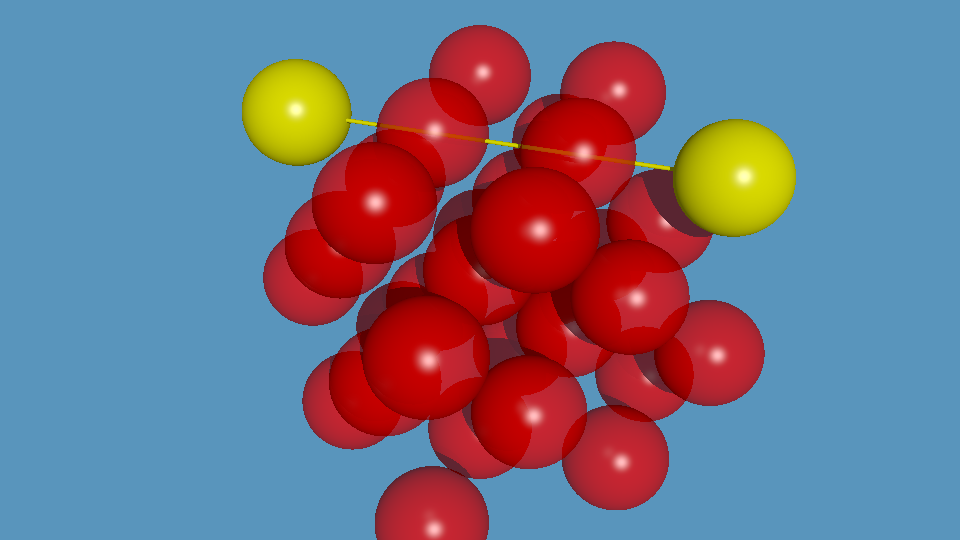

In [6]:
scene.renderScene("var.png")
scene.createSceneFile("x.pov")
Image(filename='var.png')

#### Iterate

Jitter the initial condition, then perform 50 iterations. The 'shrinkage' here is a reflection of how much the curve expands/contracts with the current iteration.

In [7]:
var.jitter(0.01)     # Apply small random noise to nudge points away from saddles.
for _ in range(50):  # Nudge curve 50 times
    shrinkage = var.adaptiveIterateAndUpdate()
    print(_, shrinkage)

0 0.9937280416488647
1 1.0096780061721802
2 1.0123790502548218
3 1.0071890354156494
4 1.0063430070877075
5 1.0066114664077759
6 0.9987187385559082
7 0.9993084669113159
8 0.9999457597732544
9 1.0004805326461792
10 1.0010581016540527
11 1.0042815208435059
12 1.0070604085922241
13 1.0014399290084839
14 1.004831075668335
15 1.0030707120895386
16 1.0061798095703125
17 1.0044994354248047
18 1.0051573514938354
19 1.0055971145629883
20 1.005933165550232
21 1.0059196949005127
22 1.0057421922683716
23 1.0056540966033936
24 1.0051583051681519
25 1.004391074180603
26 1.0032813549041748
27 1.0032451152801514
28 1.002968192100525
29 1.0028316974639893
30 1.0027377605438232
31 1.0024796724319458
32 1.0022169351577759
33 1.0020413398742676
34 1.0017350912094116
35 1.0013550519943237
36 1.0010552406311035
37 1.0004887580871582
38 1.000001311302185
39 1.000006914138794
40 1.0000090599060059
41 1.0000078678131104
42 1.0000077486038208
43 1.000009298324585
44 1.0000076293945312
45 1.000007152557373
46 1.0

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


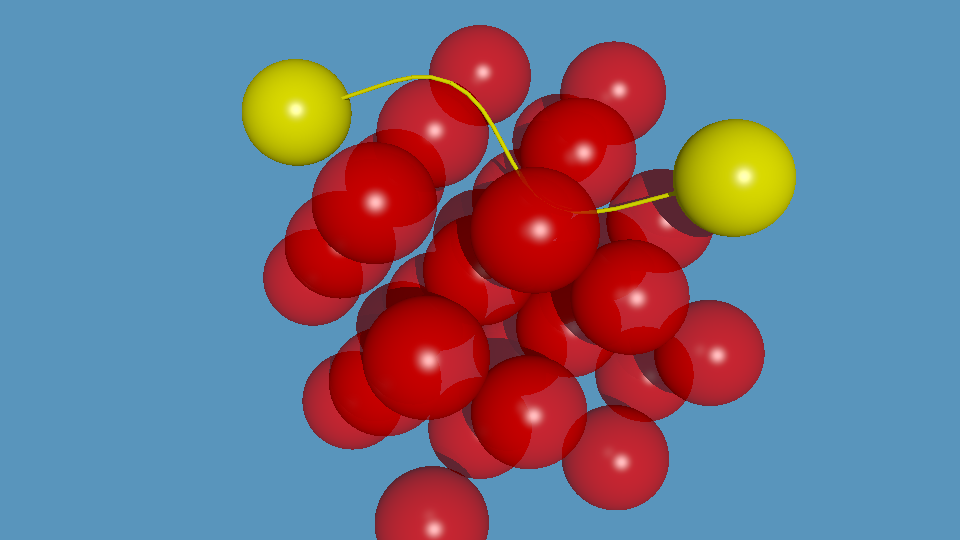

In [8]:
scene.renderScene("var.png")
scene.createSceneFile("x.pov")
Image(filename='var.png')